In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('alex_paper.mplstyle')
import compute_S_rate
import auxiliary_functions
from scipy import sparse

In [5]:
def heat_kernel_path_graph(N: int, t: float) -> np.ndarray:
    """
    Return the heat‑diffusion transition matrix e^{−tL} for the simple path
    graph P_N (vertices 0,…,N−1 with edges i–(i+1)).

    Parameters
    ----------
    N : int
        Number of vertices of the path graph.
    t : float
        Diffusion time (non‑negative).

    Returns
    -------
    T : ndarray, shape (N, N)
        Row‑stochastic transition matrix whose (i, j) entry gives
        the probability of being at vertex j at time t when starting
        from vertex i.
    """
    # Eigenvalues λ_k = 2(1 − cos(π k / N)),  k = 0,…,N−1
    k = np.arange(N)
    lambdas = 2.0 * (1.0 - np.cos(np.pi * k / N))

    # Eigenvectors:
    #   – k = 0: constant vector (normalised)
    #   – k ≥ 1: DST‑II cosine modes with a half‑shift (j + 0.5)
    j = np.arange(N).reshape(-1, 1)          # column of vertex indices
    U0 = np.ones((N, 1)) / np.sqrt(N)        # constant eigenvector
    k1 = np.arange(1, N).reshape(1, -1)      # row of mode indices
    U_rest = np.sqrt(2.0 / N) * np.cos(np.pi * k1 * (j + 0.5) / N)

    U = np.hstack((U0, U_rest))              # full eigenvector matrix (orthonormal)

    # Heat kernel: U · diag(e^{−λ_k t}) · Uᵀ
    T = (U * np.exp(-lambdas * t)) @ U.T

    # Numerical clean‑up: set tiny negative round‑off to zero and renormalise rows
    T = np.clip(T, 0.0, None)
    T /= T.sum(axis=1, keepdims=True)

    return sparse.csr_matrix(T)

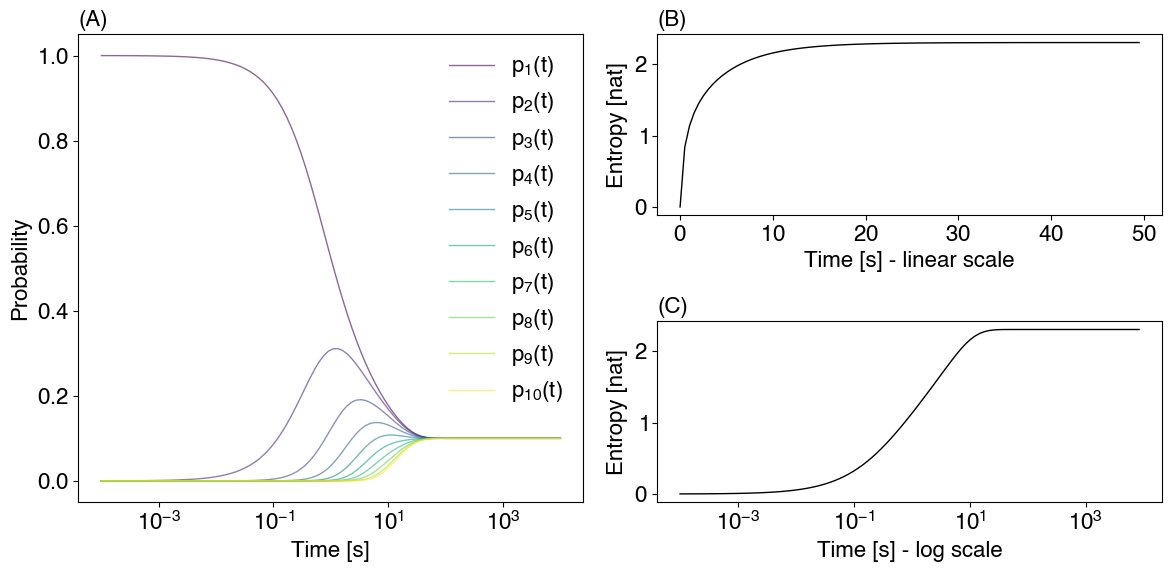

In [ ]:
# Create the figure and grid specification
fig = plt.figure(figsize=(12, 6))  # Taller figure to accommodate two plots on the right
gs = fig.add_gridspec(2, 2)  # 2 rows, 2 columns

# Define parameters
N = 10
lambda_value = 1.0
time_log = np.logspace(-4, 4, 100)
time_lin = np.linspace(0, 50, 100)

# Generate transition matrices
Transitions_logscale = [heat_kernel_path_graph(N, t) for t in time_log]
Transitions_linscale = [heat_kernel_path_graph(N, t) for t in time_lin]
p0 = np.zeros(N)
p0[0] = 1

# Left column (full height): Plot A
ax_a = fig.add_subplot(gs[:, 0])  # Use both rows of the first column

# Plot transition probabilities on primary y-axis
colours = auxiliary_functions.generate_viridis_colors(N)
for i in range(N):
    array_Transitions_endpoint = [T.toarray()[0, i] for T in Transitions_logscale]
    ax_a.plot(time_log, array_Transitions_endpoint, color=colours[i], alpha=0.6, label=fr"$p_{{{i+1}}}(t)$")

ax_a.set_xlabel("Time [s]")
ax_a.set_ylabel("Probability")
ax_a.set_xscale('log')
ax_a.set_title("(A)", loc='left')
ax_a.legend(loc='upper right')

# Compute entropies
entropy_logscale = compute_S_rate.compute_conditional_entropy(
    list_T=Transitions_logscale,
    lamda=lambda_value,
    force_csr=True,
    time_domain=list(np.arange(0, len(time_log) - 1)),
    p0=p0
)

entropy_linscale = compute_S_rate.compute_conditional_entropy(
    list_T=Transitions_linscale,
    lamda=lambda_value,
    force_csr=True,
    time_domain=list(np.arange(0, len(time_lin) - 1)),
    p0=p0
)

# Top-right: Entropy with linear scale x-axis
ax_b = fig.add_subplot(gs[0, 1])
entropy_values_lin = entropy_linscale[list(entropy_linscale.keys())[0]][1:]
ax_b.plot(time_lin[:-1], entropy_values_lin, color="k")
ax_b.set_xlabel("Time [s] - linear scale")
ax_b.set_ylabel("Entropy [nat]")
ax_b.set_title("(B)", loc='left')

# Bottom-right: Entropy with log scale x-axis
ax_c = fig.add_subplot(gs[1, 1])
entropy_values_log = entropy_logscale[list(entropy_logscale.keys())[0]][1:]
ax_c.plot(time_log[:-1], entropy_values_log, color='k')
ax_c.set_xscale('log')
ax_c.set_ylabel("Entropy [nat]")
ax_c.set_xlabel("Time [s] - log scale")
ax_c.set_title("(C)", loc='left')


# Final layout and save
plt.tight_layout()
#plt.savefig('/Users/samuelkoovely/Desktop/fig_entropy/trajectories_and_path.pdf', format='pdf')
plt.show()